# Time Series Fundamentals

In this notebook I will learn

- What makes time series data differenet
- Why chronological order must be preserved
- How to create chronological train, validation, and test sets
- How to scale data without leakage
- What lookback and sliding windows mean
- How to concert a time series into supervised learning samples
- How sequence tensors are structed for LTSM and GRU models
- How to create a naive baseline forecast

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

In [2]:
number_of_points = 240

time_steps = np.arange(number_of_points)
random_generator = np.random.default_rng(42)

noise = random_generator.normal(
    loc = 0.0,
    scale = 0.5,
    size = number_of_points
)

close_prices = (
    50 + 0.08 * time_steps + 2.5 * np.sin(time_steps / 6) + noise
)

df = pd.DataFrame(
    {"date" : pd.date_range(
        start = "2025-01-02",
        periods = number_of_points,
        freq = "B"
    ),
    "close" : close_prices
})

df.head()

,date,close
0,2025-01-02,50.152359
1,2025-01-03,49.974748
2,2025-01-06,51.353212
3,2025-01-07,51.908846
4,2025-01-08,50.890407


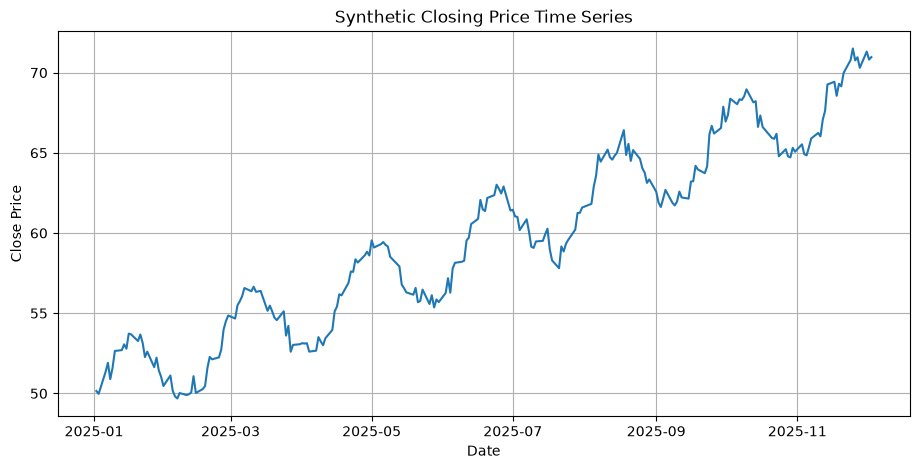

In [3]:
plt.figure(figsize = (11, 5))

plt.plot(
    df["date"],
    df["close"]
)

plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title("Synthetic Closing Price Time Series")
plt.grid(True)
plt.show()

In [4]:
train_end = int(len(df) * 0.70)
validation_end = int(len(df) * 0.85)

print("Total Samples: ", len(df))
print("Train end index: ", train_end)
print("Validation end index: ", validation_end)

Total Samples:  240
Train end index:  168
Validation end index:  204


In [5]:
train_df = df.iloc[:train_end].copy()

validation_df = df.iloc[
    train_end:validation_end
].copy()

test_df = df.iloc[
    validation_end:
].copy()

print("Training Samples: ", len(train_df))
print("Valitaion Samples: ", len(validation_df))
print("Test Samples:" , len(test_df))

Training Samples:  168
Valitaion Samples:  36
Test Samples: 36


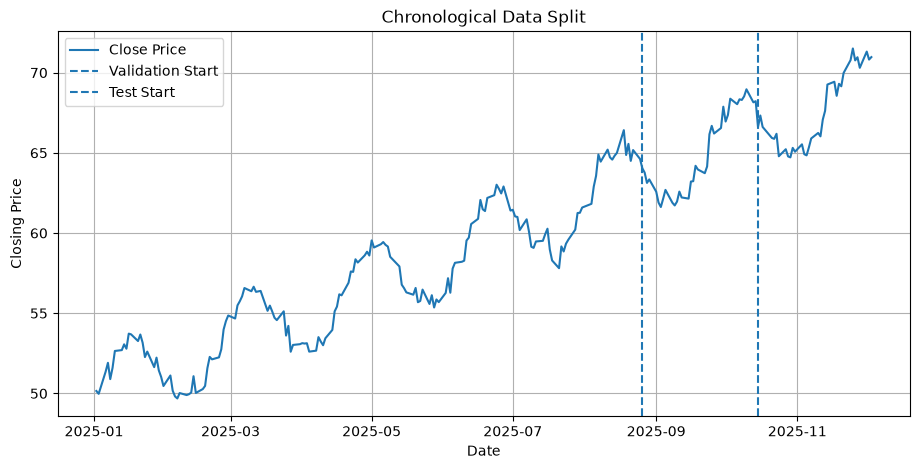

In [6]:
plt.figure(figsize = (11, 5))

plt.plot(
    df["date"],
    df["close"],
    label = "Close Price"
)

plt.axvline(
    df.iloc[train_end]["date"],
    linestyle = "--",
    label = "Validation Start"
)

plt.axvline(
    df.iloc[validation_end]["date"],
    linestyle = "--",
    label = "Test Start"
)

plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.title("Chronological Data Split")
plt.legend()
plt.grid(True)
plt.show()

In [7]:
scaler = MinMaxScaler(
    feature_range = (-1, 1)
)

scaler.fit(
    train_df[["close"]]
)

df["scaled_close"] = scaler.transform(
    df[["close"]]
).ravel()

df.head()

,date,close,scaled_close
0,2025-01-02,50.152359,-0.944368
1,2025-01-03,49.974748,-0.965603
2,2025-01-06,51.353212,-0.800795
3,2025-01-07,51.908846,-0.734364
4,2025-01-08,50.890407,-0.856128


In [8]:
df[
    ["date", "close", "scaled_close"]
].head(10)

,date,close,scaled_close
0,2025-01-02,50.152359,-0.944368
1,2025-01-03,49.974748,-0.965603
2,2025-01-06,51.353212,-0.800795
3,2025-01-07,51.908846,-0.734364
4,2025-01-08,50.890407,-0.856128
5,2025-01-09,51.599352,-0.771367
6,2025-01-10,52.647598,-0.646040
7,2025-01-13,52.700491,-0.639716
8,2025-01-14,53.061444,-0.596561
9,2025-01-15,52.787216,-0.629347


In [9]:
def create_sequences(
    values: np.ndarray,
    lookback: int
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:

    if values.ndim != 1:
        raise ValueError(
            "Values Must be a One-Dimensional Array"
        )
    if lookback <= 0:
        raise ValueError(
            "Lookback must be greater than zero"
        )

    if len(values) <= lookback:
        raise ValueError(
            "The Series must be longer than lookback"
        )

    sequence_list = []
    target_list = []
    target_index_list = []

    for target_index in range(lookback, len(values)):
        start_index = target_index - lookback

        sequence = values[start_index:target_index]

        target = values[target_index]

        sequence_list.append(sequence)
        target_list.append(target)
        target_index_list.append(target_index)

    X = np.array(
        sequence_list,
        dtype = np.float32
    ).reshape(-1, lookback, 1)

    y = np.array(
        target_list,
        dtype = np.float32
    ).reshape(-1, 1)

    target_indices = np.array(
        target_index_list,
        dtype = np.int64
    )

    return X, y, target_indices
    

In [10]:
lookback = 20
scaled_values = df[
    "scaled_close"
].to_numpy(dtype=np.float32)

X_all, y_all, target_indices = create_sequences(
    values = scaled_values,
    lookback = lookback
)

print("X shape: ", X_all.shape)
print("y shape: ", y_all.shape)
print("Target indcies shape: ", target_indices.shape)

X shape:  (220, 20, 1)
y shape:  (220, 1)
Target indcies shape:  (220,)


In [11]:
first_sequence = X_all[0]
first_target = y_all[0]

print("Sequence shape: ", first_sequence.shape)
print("Target shape: ", first_target.shape)

print("\nScaled Sequence: ")
print(first_sequence.squeeze())

print("\nScaled Target: ")
print(first_target)

Sequence shape:  (20, 1)
Target shape:  (1,)

Scaled Sequence: 
[-0.9443683  -0.96560323 -0.80079526 -0.73436415 -0.85612786 -0.77136695
 -0.64603966 -0.6397158  -0.59656054 -0.6293471  -0.51684153 -0.5222201
 -0.57207304 -0.52347076 -0.58460164 -0.6915993  -0.65082693 -0.76661956
 -0.69572514 -0.7913326 ]

Scaled Target: 
[-0.8393009]


In [12]:
first_sequence_original = scaler.inverse_transform(
    first_sequence
).ravel()

first_target_original = scaler.inverse_transform(
    first_target.reshape(1, 1)
)[0, 0]

sequence_example_df = pd.DataFrame({
    "day_in_sequence": np.arange(
        1,
        lookback + 1,
    ),
    "close_price": first_sequence_original,
})

display(sequence_example_df)

print(
    "Target price after the sequence:",
    round(first_target_original, 2),
)

,day_in_sequence,close_price
0,1,50.152359
1,2,49.974747
2,3,51.353210
3,4,51.908848
4,5,50.890408
5,6,51.599354
6,7,52.647594
7,8,52.700493
8,9,53.061447
9,10,52.787212


Target price after the sequence: 51.03


In [13]:
train_mask = (
    target_indices < train_end
)

validation_mask = (
    (target_indices >= train_end)
    & (target_indices < validation_end)
)

test_mask = (
    target_indices >= validation_end
)

X_train = X_all[train_mask]
y_train = y_all[train_mask]

X_validation = X_all[validation_mask]
y_validation = y_all[validation_mask]

X_test = X_all[test_mask]
y_test = y_all[test_mask]

In [14]:
print("Training:")
print("X:", X_train.shape)
print("y:", y_train.shape)

print("\nValidation:")
print("X:", X_validation.shape)
print("y:", y_validation.shape)

print("\nTest:")
print("X:", X_test.shape)
print("y:", y_test.shape)

Training:
X: (148, 20, 1)
y: (148, 1)

Validation:
X: (36, 20, 1)
y: (36, 1)

Test:
X: (36, 20, 1)
y: (36, 1)


In [15]:
train_target_dates = df.iloc[
    target_indices[train_mask]
]["date"]

validation_target_dates = df.iloc[
    target_indices[validation_mask]
]["date"]

test_target_dates = df.iloc[
    target_indices[test_mask]
]["date"]

print(
    "Last training target:",
    train_target_dates.iloc[-1],
)

print(
    "First validation target:",
    validation_target_dates.iloc[0],
)

print(
    "Last validation target:",
    validation_target_dates.iloc[-1],
)

print(
    "First test target:",
    test_target_dates.iloc[0],
)

Last training target: 2025-08-25 00:00:00
First validation target: 2025-08-26 00:00:00
Last validation target: 2025-10-14 00:00:00
First test target: 2025-10-15 00:00:00


In [16]:
X_train_tensor = torch.from_numpy(X_train)
y_train_tensor = torch.from_numpy(y_train)

X_validation_tensor = torch.from_numpy(
    X_validation
)
y_validation_tensor = torch.from_numpy(
    y_validation
)

X_test_tensor = torch.from_numpy(X_test)
y_test_tensor = torch.from_numpy(y_test)

In [17]:
print(
    "X train tensor:",
    X_train_tensor.shape,
)

print(
    "y train tensor:",
    y_train_tensor.shape,
)

X train tensor: torch.Size([148, 20, 1])
y train tensor: torch.Size([148, 1])


In [18]:
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor,
)

validation_dataset = TensorDataset(
    X_validation_tensor,
    y_validation_tensor,
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=32,
    shuffle=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
)

In [19]:
batch_X, batch_y = next(
    iter(train_loader)
)

print("Batch X shape:", batch_X.shape)
print("Batch y shape:", batch_y.shape)

Batch X shape: torch.Size([32, 20, 1])
Batch y shape: torch.Size([32, 1])


In [20]:
baseline_predictions_scaled = X_test[
    :,
    -1,
    0,
].reshape(-1, 1)

actual_test_scaled = y_test

In [21]:
baseline_predictions = scaler.inverse_transform(
    baseline_predictions_scaled
).ravel()

actual_test_values = scaler.inverse_transform(
    actual_test_scaled
).ravel()

In [22]:
baseline_mae = mean_absolute_error(
    actual_test_values,
    baseline_predictions,
)

baseline_mse = mean_squared_error(
    actual_test_values,
    baseline_predictions,
)

baseline_rmse = np.sqrt(
    baseline_mse
)

print(f"Baseline MAE : {baseline_mae:.4f}")
print(f"Baseline MSE : {baseline_mse:.4f}")
print(f"Baseline RMSE: {baseline_rmse:.4f}")

Baseline MAE : 0.5783
Baseline MSE : 0.4916
Baseline RMSE: 0.7011


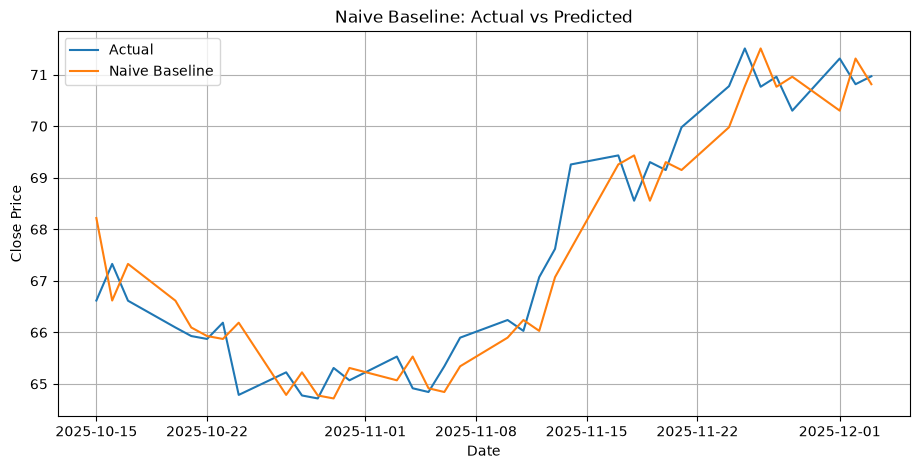

In [23]:
test_dates = df.iloc[
    target_indices[test_mask]
]["date"].to_numpy()

plt.figure(figsize=(11, 5))

plt.plot(
    test_dates,
    actual_test_values,
    label="Actual",
)

plt.plot(
    test_dates,
    baseline_predictions,
    label="Naive Baseline",
)

plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title("Naive Baseline: Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.show()

In [24]:
window_examples = []

for example_index in range(3):
    input_start = target_indices[example_index] - lookback
    input_end = target_indices[example_index] - 1
    target_index = target_indices[example_index]

    window_examples.append({
        "example": example_index + 1,
        "input_start_index": input_start,
        "input_end_index": input_end,
        "target_index": target_index,
    })

pd.DataFrame(window_examples)

,example,input_start_index,input_end_index,target_index
0,1,0,19,20
1,2,1,20,21
2,3,2,21,22


## Conclusion

In this notebook:

- I created and visualized a time series.
- I preserved chronological order when splitting the data.
- I created training, validation and test periods.
- I fitted the scaler only on training data to prevent leakage.
- I converted the time series into supervised learning samples.
- I used a lookback window of 20 time steps.
- I created tensors with the shape:
  `[samples, sequence length, features]`.
- I created DataLoaders for sequence data.
- I built a naive baseline using the final value of each input sequence.
- I evaluated the baseline in the original price scale.

The model input structure for the next stages will be:

`20 historical closing prices → next closing price`